In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os;
file_path = os.path.join('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud', 'creditcard.csv')

# Create the DataFrame
data = pd.read_csv(file_path)

In [3]:
#1. Time since previous transaction
data['time_since_previous_transaction'] = data['Time'].diff().fillna(0)

# 2. Transaction hour
data['hour'] = (data['Time']//3600) % 24

# 3. is_night_time
data['is_night_time'] = data['hour'].apply(lambda x: 1 if 0 <= x <= 6 else 0)

#1. Log transformed
data['log_amount'] = np.log(data['Amount'] + 1)

#2. Amount Z-score
data['amount_zscore'] = (data['Amount'] - data['Amount'].mean()) / data['Amount'].std()

#3. Rolling amount mean (compute over last 60s)

    # 3.1 Create a temporary datetime index using the 'Time' column (seconds)
data.index = pd.to_datetime(data['Time'], unit='s')

    # 3.2 Calculate the rolling mean of 'Amount' over the last 60 seconds
data['rolling_amount_mean_60s'] = (
    data['Amount']
    .rolling(window='60s')
    .mean()
)

    #3.3 Reset the index back to the default (0, 1, 2...)
data = data.reset_index(drop=True)

data = data.drop(columns=[
    'Amount'
])

In [4]:
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
)

def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name, method):
    """Calculates and returns key metrics, including AUPRC."""

    # Calculate Precision-Recall AUC (AUPRC) - Recommended for imbalance
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Calculate other key metrics
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    recall = recall_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)

    # Calculate Confusion Matrix for review
    cm = confusion_matrix(y_true, y_pred_class)
    print("confusion_matrix:\n",cm)

    tn, fp, fn, tp = cm.ravel()

    results = {
        'Model': model_name,
        'Method': method,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Recall (Fraud)': recall,
        'Precision (Fraud)': precision,
        'F1-Score': f1,
        'True Positives (TP)': tp,
        'False Negatives (FN)': fn  # Missed Fraud - critical risk
    }
    return results

final_results = []

In [5]:
from sklearn.model_selection import train_test_split
X = data.drop('Class', axis=1)
y = data['Class']

# Perform a stratified train-test split to ensure both sets have the same fraud ratio (0.17%)
# Using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

cols = ['Time', 'log_amount','time_since_previous_transaction','hour','is_night_time','amount_zscore','rolling_amount_mean_60s']

preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), cols)
    ],
    remainder='passthrough'
)

In [7]:
## Handle Imbalance (SMOTE Example for Training Data)

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

LR - CW

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

lr_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        C=0.01,
    ))
])


lr_cw.fit(X_train, y_train)
y_pred_proba_cw = lr_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = lr_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "LR","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[83162  2133]
 [   20   128]]
Model                         LR
Method                        CW
PR-AUC                  0.684941
ROC-AUC                 0.970299
Recall (Fraud)          0.864865
Precision (Fraud)       0.056612
F1-Score                0.106268
True Positives (TP)          128
False Negatives (FN)          20
dtype: object


In [8]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_cw.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_cw.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                   Feature  Coefficient
2                            remainder__V4     0.894960
13                          remainder__V22     0.396352
0   scale__time_since_previous_transaction     0.331735
1                     scale__amount_zscore     0.262496
12                          remainder__V21     0.211374
3                            remainder__V5     0.168389
14                          remainder__V24     0.051598
16                          remainder__V28     0.000000
15                          remainder__V27    -0.069170
4                            remainder__V7    -0.095271
5                            remainder__V9    -0.181885
11                          remainder__V20    -0.206644
10                          remainder__V16    -0.242750
7                           remainder__V12    -0.377422
8                           remainder__V13    -0.541738
6                           remainder__V10    -0.653794
9                           remainder__V14    -0

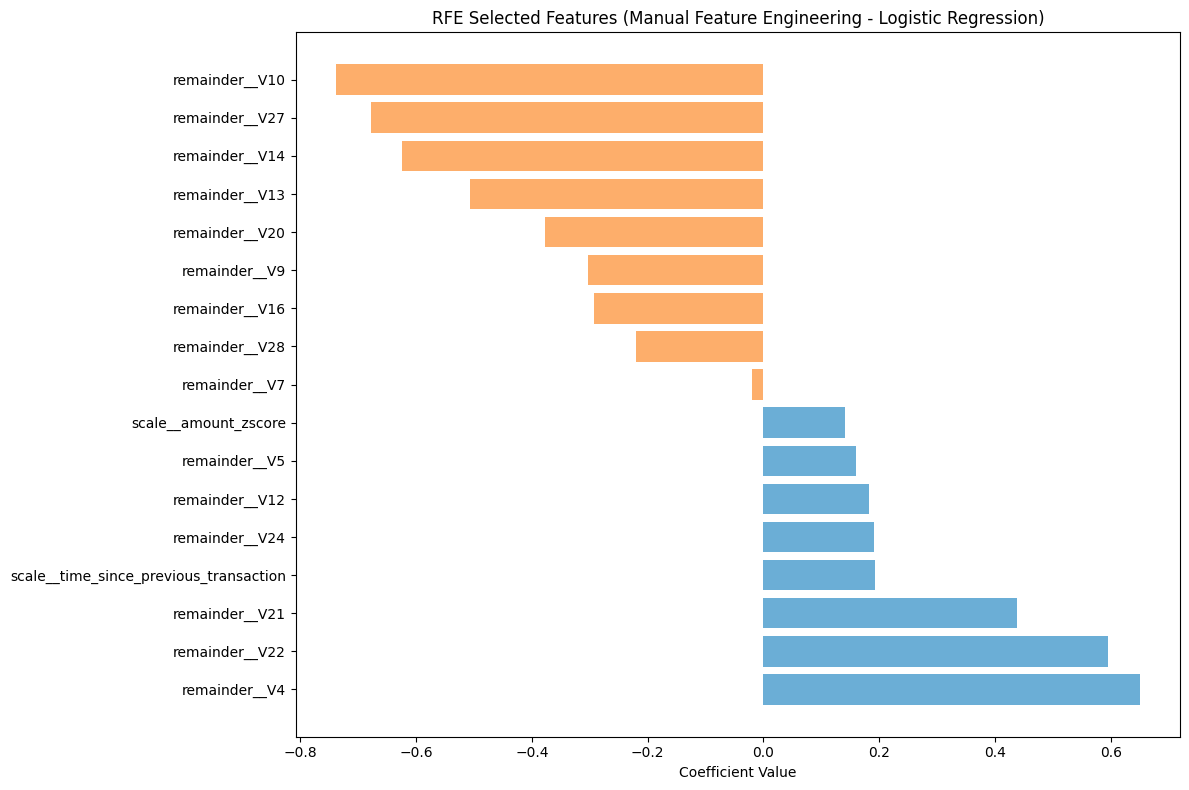

In [9]:
feature_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()
selector = lr_cw.named_steps['selector']
selected_mask = selector.support_
selected_features = feature_names[selected_mask]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get coefficients
coefs = selector.estimator_.coef_[0]


# Use absolute value for ranking
#importance = np.abs(coefs)
importance = coefs

# Sort
indices = np.argsort(importance)

sorted_importance = importance[indices]
sorted_features = np.array(selected_features)[indices]

# Soft professional color
#colors = cm.GnBu(np.linspace(0.3, 0.8, len(indices)))
colors = ['#6baed6' if c > 0 else '#fdae6b' for c in sorted_importance]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), sorted_importance, color=colors)

plt.yticks(range(len(indices)), sorted_features)
plt.xlabel("Coefficient Value")
plt.title("RFE Selected Features (Manual Feature Engineering - Logistic Regression)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

LR - SMOTE

In [10]:
from imblearn.pipeline import Pipeline as ImbPipeline

lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=10)),
    ('classifier', LogisticRegression(
        random_state=42,
        C=0.01,
        max_iter=1000,
        solver='liblinear',
        penalty='l1',
        class_weight=None,
    ))
])

# Train on the SMOTE-resampled training data
lr_smote.fit(X_train, y_train)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = lr_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "LR", "SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[83264  2031]
 [   20   128]]
Model                         LR
Method                     SMOTE
PR-AUC                  0.685371
ROC-AUC                 0.964751
Recall (Fraud)          0.864865
Precision (Fraud)       0.059287
F1-Score                0.110967
True Positives (TP)          128
False Negatives (FN)          20
dtype: object


In [11]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_smote.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_smote.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

          Feature  Coefficient
2   remainder__V4     1.002681
1     scale__hour     0.318456
5  remainder__V11     0.314876
3   remainder__V5     0.295505
9  remainder__V16    -0.280387
7  remainder__V13    -0.423963
0     scale__Time    -0.546235
6  remainder__V12    -0.606246
4  remainder__V10    -0.717698
8  remainder__V14    -0.943709


RF - CW

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs = -1,
        class_weight='balanced',
        criterion='entropy',
        max_depth=30,
        max_features='sqrt',
        min_samples_split=2
    ))
])

rf_cw.fit(X_train, y_train)
y_pred_proba_cw = rf_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = rf_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "RF","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[85292     3]
 [   37   111]]
Model                         RF
Method                        CW
PR-AUC                  0.827189
ROC-AUC                 0.940843
Recall (Fraud)              0.75
Precision (Fraud)       0.973684
F1-Score                0.847328
True Positives (TP)          111
False Negatives (FN)          37
dtype: object


In [13]:
# 1. Get original names from preprocessor
feature_names = rf_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_cw.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 10 out of 35 features.
remainder__V14    0.274871
remainder__V10    0.186521
remainder__V4     0.137270
remainder__V17    0.127684
remainder__V12    0.118528
remainder__V11    0.054193
remainder__V3     0.031573
remainder__V16    0.030038
remainder__V7     0.022366
remainder__V2     0.016955
dtype: float64


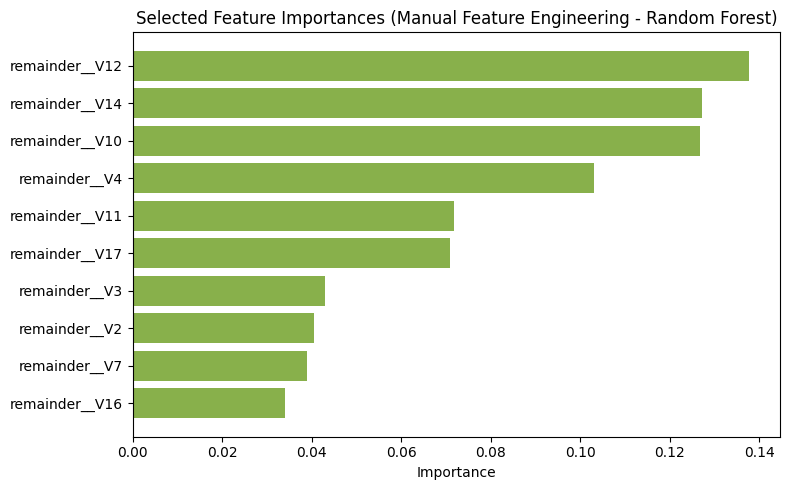

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#88B04B'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (Manual Feature Engineering - Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

RF - SMOTE

In [15]:
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs = -1,
        class_weight=None,
        criterion='entropy',
        max_depth=30,
        max_features='log2',
        min_samples_split=10
    ))
])

# Train on the SMOTE-resampled training data
rf_smote.fit(X_train, y_train)
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = rf_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "RF","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[85242    53]
 [   26   122]]
Model                         RF
Method                     SMOTE
PR-AUC                  0.816292
ROC-AUC                  0.95831
Recall (Fraud)          0.824324
Precision (Fraud)       0.697143
F1-Score                0.755418
True Positives (TP)          122
False Negatives (FN)          26
dtype: object


In [16]:
# 1. Get original names from preprocessor
feature_names = rf_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_smote.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 10 out of 35 features.
remainder__V14    0.278697
remainder__V10    0.182631
remainder__V17    0.120859
remainder__V4     0.120376
remainder__V12    0.120297
remainder__V11    0.062708
remainder__V3     0.035481
remainder__V16    0.032511
remainder__V7     0.023802
remainder__V2     0.022638
dtype: float64


XGB - CW

In [10]:
!pip install xgboost

In [11]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1] 
xgb_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        max_depth=6,
        gamma=1,
        learning_rate=0.05,
        n_estimators=200,
        n_jobs=-1
    ))
])

xgb_cw.fit(X_train, y_train)
y_pred_proba_cw = xgb_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = xgb_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "XGB","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[85245    50]
 [   28   120]]
Model                        XGB
Method                        CW
PR-AUC                  0.813681
ROC-AUC                 0.966981
Recall (Fraud)          0.810811
Precision (Fraud)       0.705882
F1-Score                0.754717
True Positives (TP)          120
False Negatives (FN)          28
dtype: object


In [19]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_cw.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 18 out of 35
remainder__V14    0.619770
remainder__V4     0.070781
remainder__V12    0.047296
remainder__V10    0.030706
remainder__V21    0.027143
remainder__V18    0.022111
remainder__V17    0.021884
remainder__V8     0.019801
remainder__V22    0.019372
remainder__V27    0.019024
dtype: float32


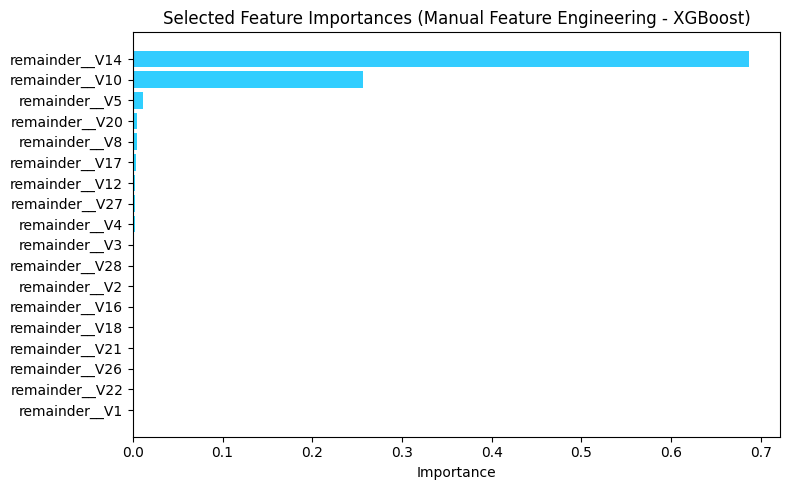

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = cm.cool(np.linspace(0.1, 0.2, len(indices)))


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (Manual Feature Engineering - XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

XGB - SMOTE

In [21]:
xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=None,
        max_depth=None,
        gamma=1,
        learning_rate=0.1,
        n_estimators=100,
    ))
])

# Train on the SMOTE-resampled training data
xgb_smote.fit(X_train, y_train)
y_pred_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = xgb_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "XGBoost","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[85068   227]
 [   25   123]]
Model                    XGBoost
Method                     SMOTE
PR-AUC                  0.801657
ROC-AUC                 0.970316
Recall (Fraud)          0.831081
Precision (Fraud)       0.351429
F1-Score                0.493976
True Positives (TP)          123
False Negatives (FN)          25
dtype: object


In [22]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_smote.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 18 out of 35
remainder__V14                            0.644696
remainder__V4                             0.068051
scale__time_since_previous_transaction    0.046054
remainder__V10                            0.032627
remainder__V8                             0.020728
remainder__V12                            0.019910
remainder__V3                             0.019461
remainder__V13                            0.016870
remainder__V11                            0.016782
remainder__V25                            0.016446
dtype: float32


In [23]:
results_df = pd.DataFrame(final_results)
print(results_df[[
    'Model',
    'Method',
    'PR-AUC',
    'ROC-AUC',
    'Recall (Fraud)',
    'Precision (Fraud)',
    'F1-Score',
    'True Positives (TP)',
    'False Negatives (FN)'
]])

     Model Method    PR-AUC   ROC-AUC  Recall (Fraud)  Precision (Fraud)  \
0       LR     CW  0.684941  0.970299        0.864865           0.056612   
1       LR  SMOTE  0.685371  0.964751        0.864865           0.059287   
2       RF     CW  0.827189  0.940843        0.750000           0.973684   
3       RF  SMOTE  0.816292  0.958310        0.824324           0.697143   
4      XGB     CW  0.813681  0.966981        0.810811           0.705882   
5  XGBoost  SMOTE  0.801657  0.970316        0.831081           0.351429   

   F1-Score  True Positives (TP)  False Negatives (FN)  
0  0.106268                  128                    20  
1  0.110967                  128                    20  
2  0.847328                  111                    37  
3  0.755418                  122                    26  
4  0.754717                  120                    28  
5  0.493976                  123                    25  


Generating SHAP for logistic Regression...


  0%|          | 0/100 [00:00<?, ?it/s]

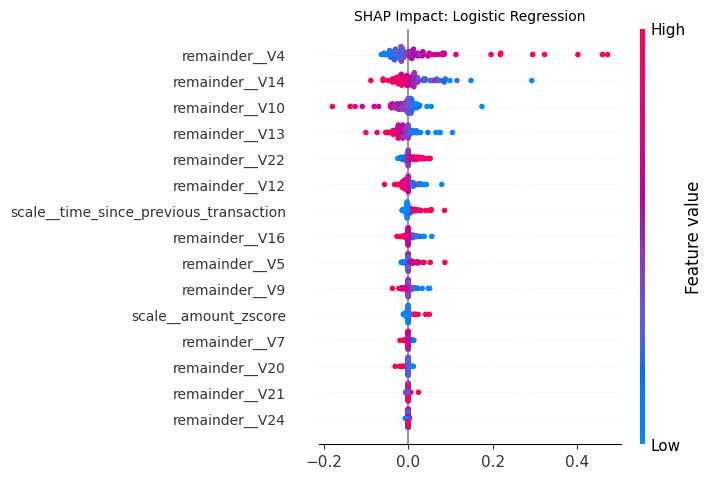

In [12]:
# --- LOGISTIC REGRESSION SHAP ---
import shap
import matplotlib.pyplot as plt
import numpy as np


model_name = 'logistic Regression' # Or 'lr_smote'
pipeline = lr_cw 

print(f"Generating SHAP for {model_name}...")

# 1. Transform data through preprocessor and RFE selector
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['selector'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['selector'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8,5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Logistic Regression", fontsize=10)
plt.show()

Generating SHAP for rf_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

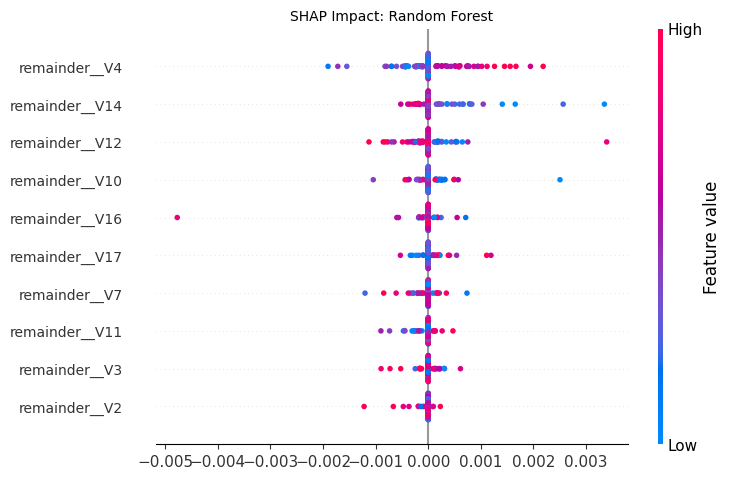

In [13]:
# --- RANDOM FOREST SHAP ---
model_name = 'rf_cw' # Or 'rf_smote'
pipeline = rf_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Random Forest", fontsize=10)
plt.show()

Generating SHAP for xgb_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

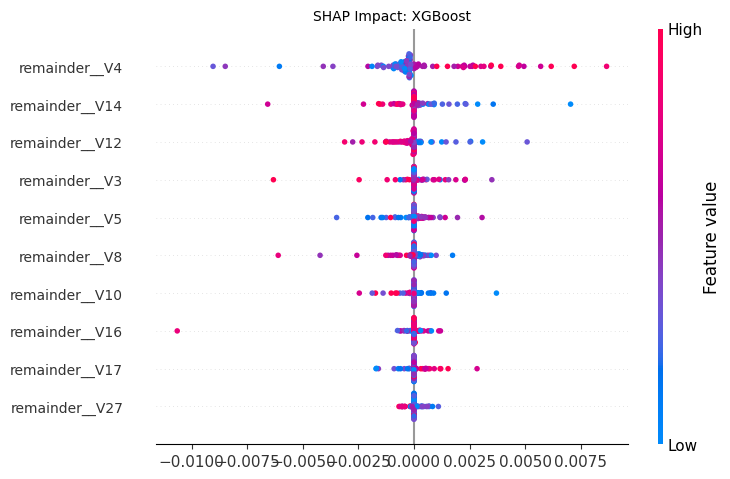

In [14]:
# --- XGBOOST SHAP ---
model_name = 'xgb_cw' # Or 'xgb_smote'
pipeline = xgb_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=10, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: XGBoost", fontsize=10)
plt.show()